In [1]:
import pandas as pd
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image_path = 'coins.jpg'
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img.shape

(312, 252, 3)

In [3]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
_, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
sure_bg = cv2.dilate(opening, kernel, iterations=3)

dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

In [4]:
ratios = [0.2, 0.4, 0.5, 0.7, 0.95]
rows = []
panels = []

for ratio in ratios:
    _, sure_fg = cv2.threshold(dist, ratio * dist.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)

    num_labels, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    result = img.copy()
    markers = cv2.watershed(result, markers)
    result[markers == -1] = (255, 0, 0)

    rows.append({'Distance Threshold': ratio, 'Foreground Markers': num_labels - 1, 'Regions': len(np.unique(markers)) - 2})
    panels.append((f'Threshold = {ratio} * max', result))

pd.DataFrame(rows)

,Distance Threshold,Foreground Markers,Regions
0,0.20,1,1
1,0.40,7,7
2,0.50,24,24
3,0.70,24,24
4,0.95,24,24


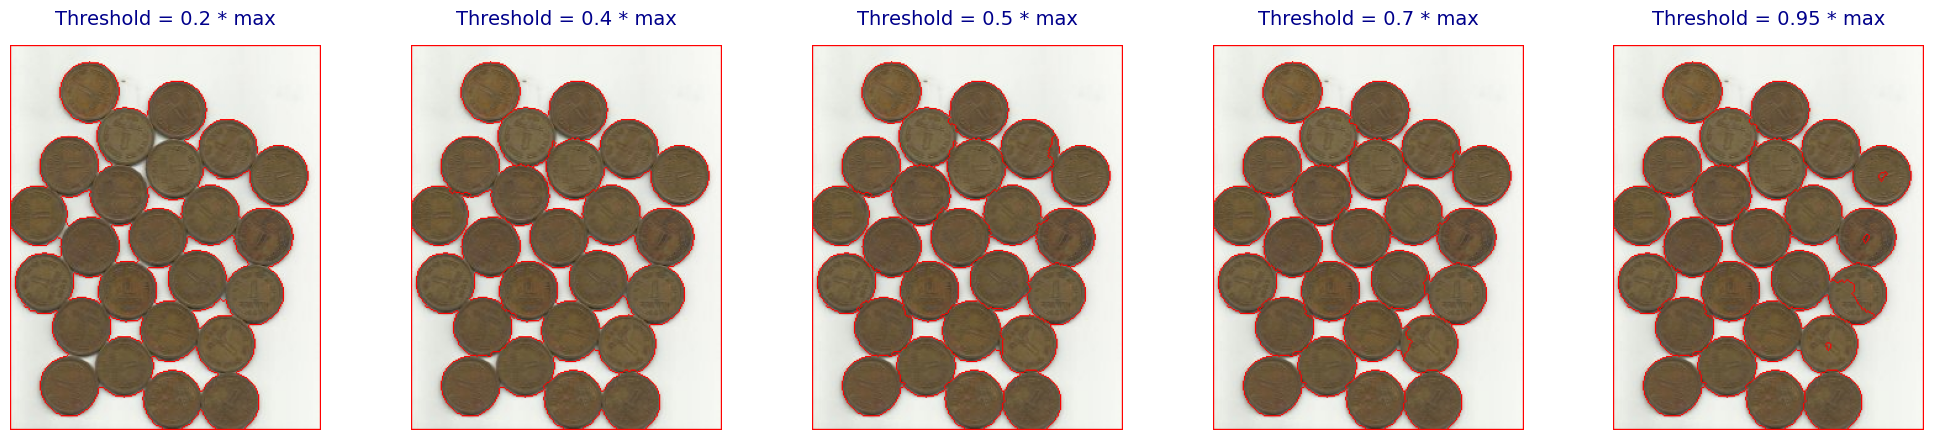

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

In [6]:
os.makedirs('output', exist_ok=True)
pd.DataFrame(rows).to_csv('output/task8_table.csv', index=False)

Experiment 1, threshold 0.2 * max: 1 foreground marker, 1 region. One blob, touching coins merged.
Experiment 2, threshold 0.4 * max: 7 markers, 7 regions. Some coins separate, many still merged.
Experiment 3, threshold 0.5 * max: 24 markers, 24 regions. Every coin separated, boundaries look right.
Experiment 4, threshold 0.7 * max: 24 markers, 24 regions. Still 24, a few stray lines inside coins.
Experiment 5, threshold 0.95 * max: 24 markers, 24 regions. Tiny markers, several coins have lines across them.

A low threshold makes the sure foreground too big so touching coins share a marker. A very high threshold makes the markers tiny and gives stray lines inside coins. Best range is about 0.5 to 0.6 of the max distance.